In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True #False if your computer sucks (mine does)

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

m1 = 1e6
m2 = 10
a = 0.8 # 0.95
e0 = 0.4 # 0.6 just spin first
xI0 = 1.0
dist = 0.4
qS = xp.pi/4
phiS = 1.0
qK = 1 
phiK = xp.pi/3
Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 0.5

chi2 = 0.0

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.0

print(use_gpu)

True


In [4]:
SK_traj = EMRIInspiral(func=SuperKludgeFlux,use_gpu=use_gpu)
add_args= [chi2, evolve_1PA, evolve_primary, evolve_2PA,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p0_ = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1, m2, a, e0, xI0, *add_args])
print(p0_)

6.3398445703337


In [5]:
filename= "rishav_CVBias"

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

# with longer signals we care less about this
t0 = 10000.0  # throw away on both ends when our orbital information is weird

In [6]:
pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

print(use_gpu)
der_order = 8
Ndelta=8
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = True,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=True
                       )
                   

der_order = 12
Ndelta = 8
stability_plot = True

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
emri_kwargs = {"T":T, "dt":dt}
# sef.waveform_generator.backend.uses_cupy

True


In [7]:
SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.0, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  88.59340741130467


In [8]:
# got from Shubham's code
def cutlervallis(waveform_truth, waveform_approx, Fisher_truth, partial_approx, params_truth, PSD_func, dt, use_gpu=False):
    """
    Calculate best-fit param points using the Cutler-Vallisneri linear-bias approximation.
    params:
        waveform_truth (ndarray) : the time-series waveform from the true template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        waveform_approx (ndarray) : the time-series waveform from the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        partial_approx (ndarray) : the time-series partial derivative of the approximate template at params_truth. ndarray of shape 'N x M' where N is number of LISA channels and M is the time-series length
        Fisher_truth (ndarray) : the Fisher matrix (log-mass units) at params_truth. ndarray of shape 'd x d'
        params_truth (ndarray) : the array of true params. ndarray of shape 'd'
        PSD_func (ndarray) : the frequency-domain LISA noise sensitivity curve. ndarray of shape 'N x L' where L is the length of the frequency series. 

    returns:
        CV_bias (ndarray): params_truth + np.linalg.inv(Fisher_truth) @ inner_product(partial_approx, waveform_truth - waveform_approx)
    """

#Equation 29 of cutler-vallisneri paper
    if use_gpu:
        xp = cp
    else:
        xp = np
        
    #waveform_truth = padding(waveform_truth, waveform_approx, use_gpu = use_gpu) #make waveform_truth the same length as waveform_approx
    delta_wave = waveform_truth - waveform_approx
    #truth contains 1 order PN and approx contains 0 order PN with deviations

    # calculate all the column-wise inner products
    inn_prods = []
    
    for j in range(len(Fisher_truth)):
        
        print("delta_wave.shape, partial_approx.shape: ", delta_wave.shape, partial_approx[j].shape)
                      
        inn_prod_j = inner_product(partial_approx[j], delta_wave, PSD=PSD_func, dt=dt, use_gpu = use_gpu) #should be a scalar
        if not use_gpu:
            inn_prod_j = xp.asarray(inn_prod_j)
        else:
            inn_prod_j = xp.asnumpy(inn_prod_j)
            
        print(f'inner_prod at j = {j}: ', inn_prod_j)
        inn_prods.append(inn_prod_j)
        
    inn_prods = np.array(inn_prods)
    # calculate all the param shifts
    delta_param_all = []
    
    for i in range(len(Fisher_truth)):
            
        delta_param_i = np.linalg.inv(Fisher_truth)[i,:]@inn_prods  #should be a scalars
        print(f"{param_names[i]} have delta {delta_param_i}")
        delta_param_all.append(delta_param_i)
        
    print('delta_param_all: ', delta_param_all)
    return params_truth + np.array(delta_param_all)


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 1577908)
wave ndim: 2
Computing SNR for parameters: (1000000.0, 10, 0.8, 7.0, 0.4, 1.0, 0.4, 0.7853981633974483, 1.0, 1, 1.0471975511965976, 0.9, 0.5, 0.4, 0.0, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 88.59340741130467
calculating stable deltas...
Gamma_ii for m1: 1130.0111833189178
Gamma_ii for m1: 1130.0111833183623
Gamma_ii for m1: 1130.0111833172416
Gamma_ii for m1: 1130.0111833457745
Gamma_ii for m1: 1130.0111831083852
Gamma_ii for m1: 1130.0111833256256
Gamma_ii for m1: 1130.011182653477
Gamma_ii for m1: 1130.0111844732398
Gamma_ii for m1: 1130.0111734291002
Gamma_ii for m1: 1130.011210727389
Gamma_ii for m1: 1130.0112721626524
Gamma_ii for m1: 1130.0113837923964
[np.float64(4.915649484783198e-13), np.float64(9.917820839345236e-13), np.float64(2.5250099802742313e-11), np.float64(2.1007691076103426e-10), np.float64(1.9224616185692498e-10), np.float64(5.948159227239691e-10)

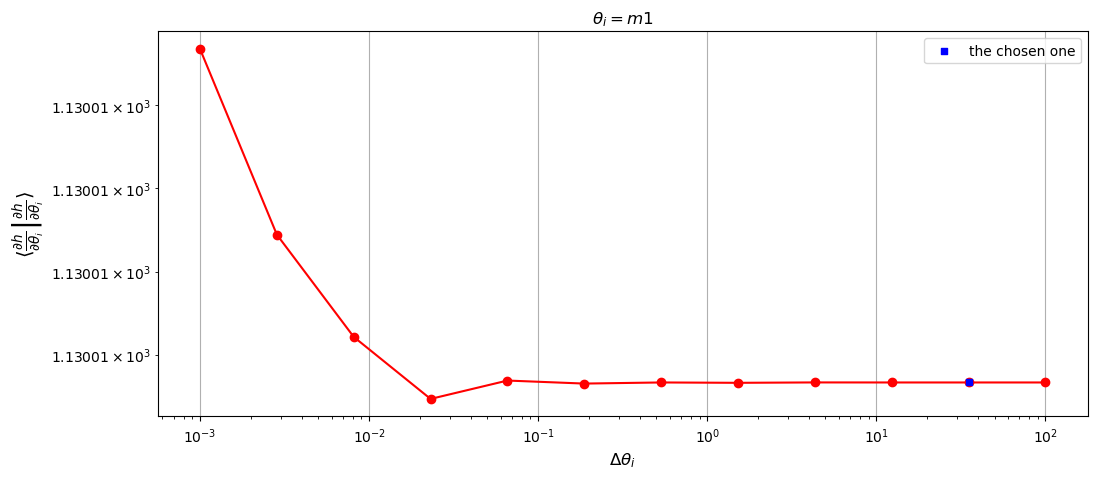

Gamma_ii for m2: 184233315318.33856
Gamma_ii for m2: 184233315309.7379
Gamma_ii for m2: 184233315365.15424
Gamma_ii for m2: 184233315325.18866
Gamma_ii for m2: 184233315639.4562
Gamma_ii for m2: 184233315841.46835
Gamma_ii for m2: 184233315788.65738
Gamma_ii for m2: 184233310996.30402
Gamma_ii for m2: 184233313114.84595
Gamma_ii for m2: 184233297049.64267
Gamma_ii for m2: 184233274085.17056
Gamma_ii for m2: 184233478934.5564
[np.float64(4.668345113475603e-11), np.float64(3.007942439234997e-10), np.float64(2.1692914824515914e-10), np.float64(1.7058127978461946e-09), np.float64(1.0965017107433705e-09), np.float64(2.8665268219823867e-10), np.float64(2.6012415111690907e-08), np.float64(1.1499233745157172e-08), np.float64(8.720032445198565e-08), np.float64(1.2464888452406907e-07), np.float64(1.1119009803126338e-06)]
0


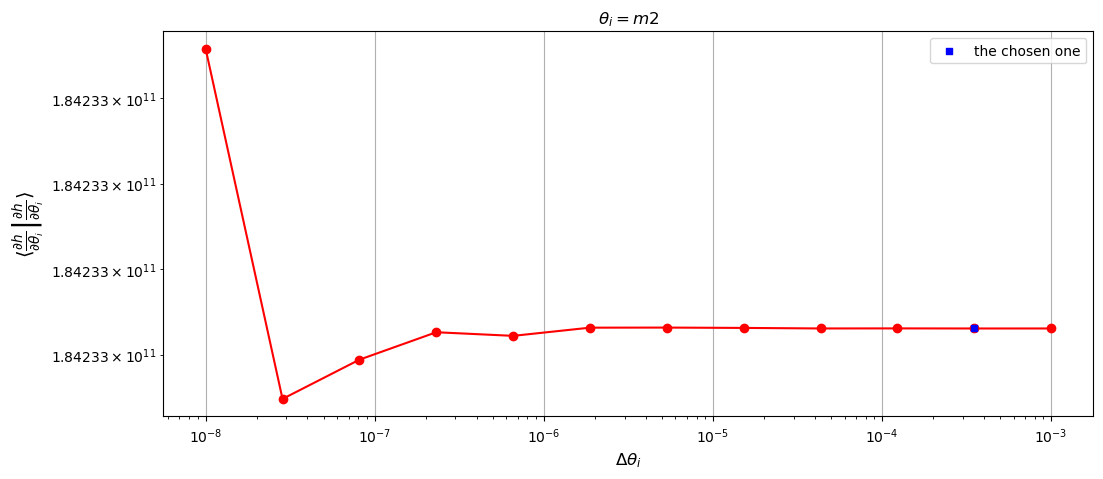

Gamma_ii for a: 19660600464522.73
Gamma_ii for a: 19660603792685.55
Gamma_ii for a: 19660630271680.43
Gamma_ii for a: 19660580391491.836
Gamma_ii for a: 19660493575758.76
Gamma_ii for a: 19660137525786.39
Gamma_ii for a: 19661911163037.15
Gamma_ii for a: 19661419163448.727
Gamma_ii for a: 19662020004321.816
Gamma_ii for a: 19673985097754.613
Gamma_ii for a: 19817917489066.94
Gamma_ii for a: 19802381597716.57
[np.float64(1.6928080416079062e-07), np.float64(1.346802951533407e-06), np.float64(2.5370659258531233e-06), np.float64(4.415745349407803e-06), np.float64(1.8110248308492035e-05), np.float64(9.020675742305822e-05), np.float64(2.5023605078137982e-05), np.float64(3.055845090981373e-05), np.float64(0.0006081682675546221), np.float64(0.00726274046663743), np.float64(0.0007845466098967889)]
0


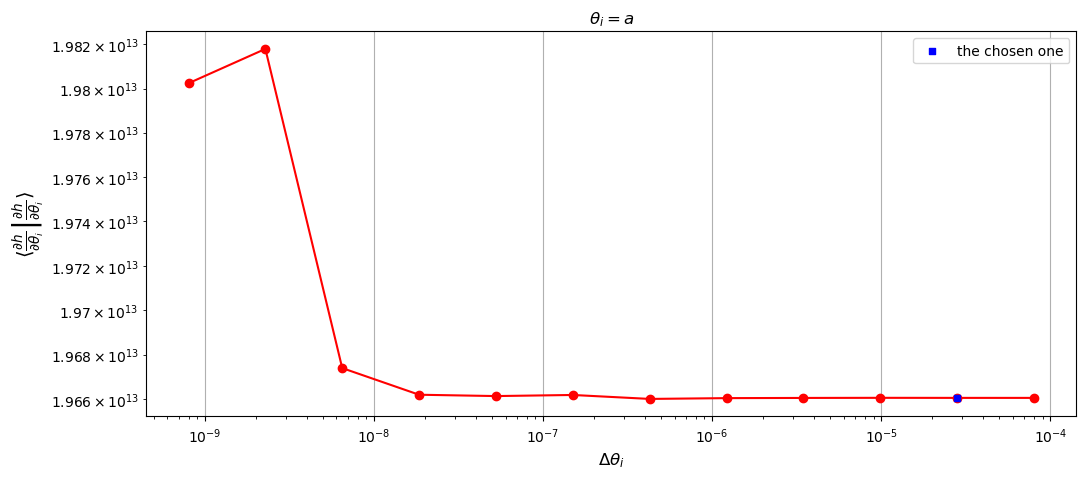

Gamma_ii for p0: 53519408660054.266
Gamma_ii for p0: 53519407547962.7
Gamma_ii for p0: 53519408726725.516
Gamma_ii for p0: 53519412758880.3
Gamma_ii for p0: 53519382194559.82
Gamma_ii for p0: 53519361825653.54
Gamma_ii for p0: 53519561907903.72
Gamma_ii for p0: 53519077675928.54
Gamma_ii for p0: 53521780239619.57
Gamma_ii for p0: 53518819284718.875
Gamma_ii for p0: 53499809323203.77
Gamma_ii for p0: 53522947754802.77
[np.float64(2.0779220351110434e-08), np.float64(2.2024959552876593e-08), np.float64(7.534004155493949e-08), np.float64(5.71088813496605e-07), np.float64(3.805894836265879e-07), np.float64(3.738488190990583e-06), np.float64(9.047838569114247e-06), np.float64(5.0494652437414134e-05), np.float64(5.532548999153179e-05), np.float64(0.0003553276498661579), np.float64(0.0004323086184453232)]
0


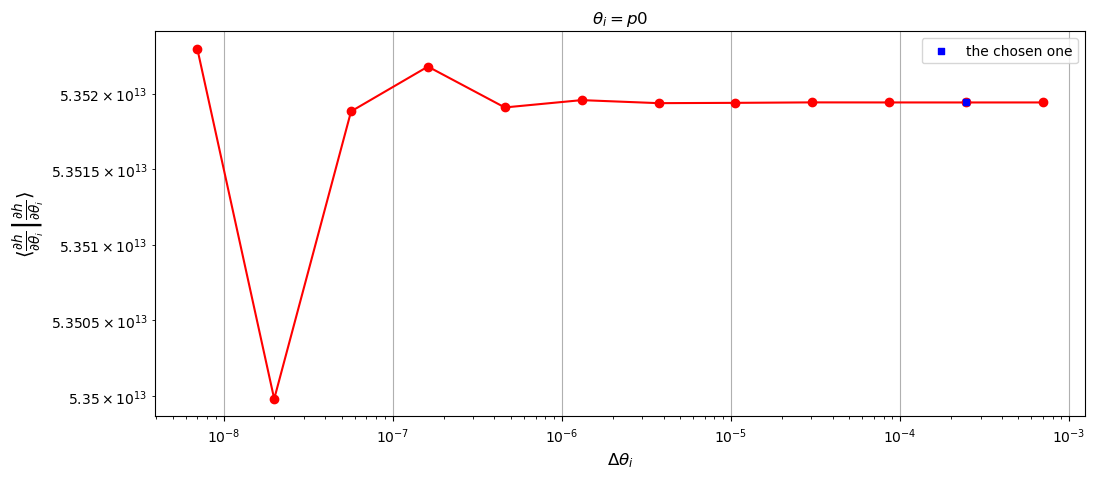

Gamma_ii for e0: 496687117098993.44
Gamma_ii for e0: 496687223033279.0
Gamma_ii for e0: 496686938885622.56
Gamma_ii for e0: 496686759984560.6
Gamma_ii for e0: 496688160759889.56
Gamma_ii for e0: 496682941415230.4
Gamma_ii for e0: 496671707996262.6
Gamma_ii for e0: 496637324651960.44
Gamma_ii for e0: 496660528357024.3
Gamma_ii for e0: 496457299531044.8
Gamma_ii for e0: 495968957017226.9
Gamma_ii for e0: 495717493194139.4
[np.float64(2.1328168040151537e-07), np.float64(5.720860248006919e-07), np.float64(3.60188908484416e-07), np.float64(2.8202309610006324e-06), np.float64(1.050840329711282e-05), np.float64(2.2617392508764623e-05), np.float64(6.923230010205753e-05), np.float64(4.6719446662358925e-05), np.float64(0.00040935811835473185), np.float64(0.0009846231440670096), np.float64(0.0005072724415416554)]
0


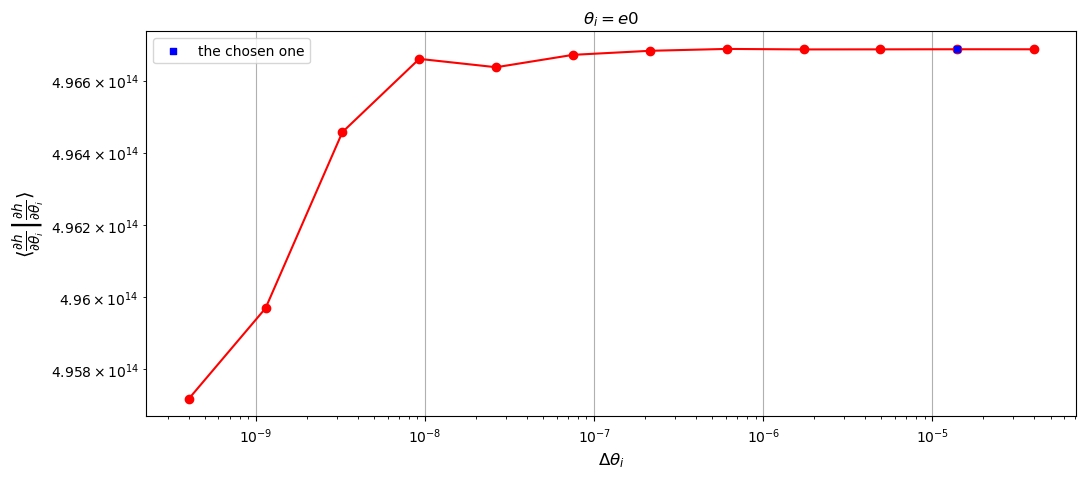

Gamma_ii for qS: 24110.161697554497
Gamma_ii for qS: 24110.161733620524
Gamma_ii for qS: 24110.16173362927
Gamma_ii for qS: 24110.161733629167
Gamma_ii for qS: 24110.161733628385
Gamma_ii for qS: 24110.161733634017
Gamma_ii for qS: 24110.161733629026
Gamma_ii for qS: 24110.16173366914
Gamma_ii for qS: 24110.16173361124
Gamma_ii for qS: 24110.161734022957
Gamma_ii for qS: 24110.161733632533
Gamma_ii for qS: 24110.16173449331
[np.float64(1.4958849031870352e-09), np.float64(3.627392113280527e-13), np.float64(4.224915938929085e-15), np.float64(3.2441318816777955e-14), np.float64(2.335774954807467e-13), np.float64(2.0702088100752636e-13), np.float64(1.663862430660492e-12), np.float64(2.4015629315730467e-12), np.float64(1.7076506665452605e-11), np.float64(1.6193348344638112e-11), np.float64(3.5701897691365815e-11)]
2


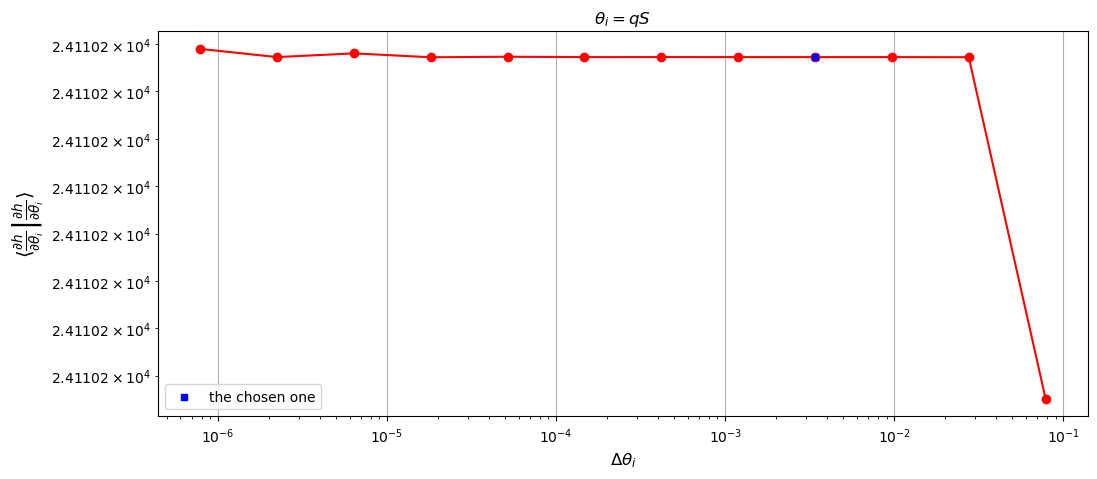

Gamma_ii for phiS: 465123.8778578232
Gamma_ii for phiS: 465123.87784622674
Gamma_ii for phiS: 465123.8778462239
Gamma_ii for phiS: 465123.8778462239
Gamma_ii for phiS: 465123.8778462239
Gamma_ii for phiS: 465123.8778462239
Gamma_ii for phiS: 465123.87784622377
Gamma_ii for phiS: 465123.8778462245
Gamma_ii for phiS: 465123.877846225
Gamma_ii for phiS: 465123.8778462238
Gamma_ii for phiS: 465123.8778462232
Gamma_ii for phiS: 465123.87784623285
[np.float64(2.493202350058738e-11), np.float64(6.132076895228479e-15), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(2.502888528664686e-16), np.float64(1.6268775436320432e-15), np.float64(1.0011554114658717e-15), np.float64(2.502888528664686e-15), np.float64(1.376588690765579e-15), np.float64(2.0773974787916488e-14)]
2


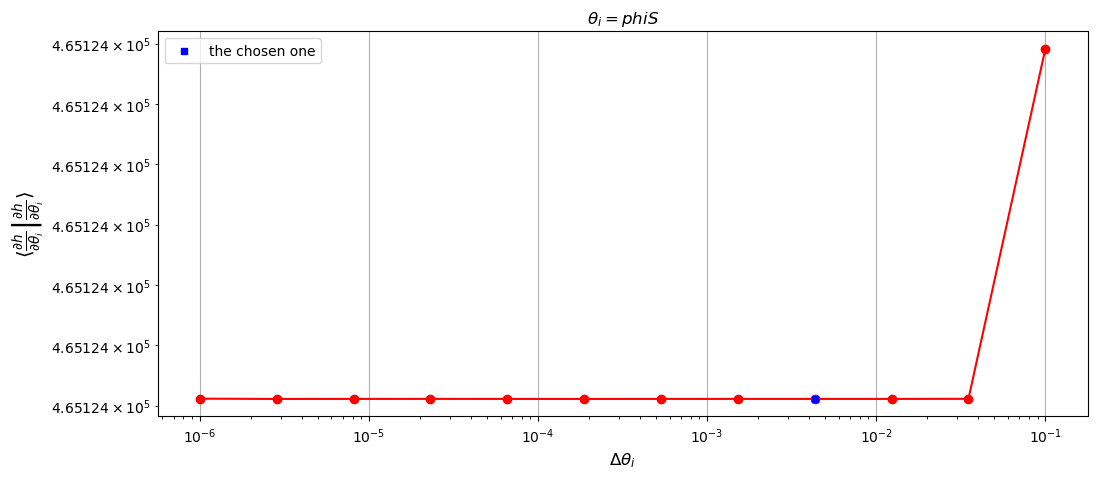

Gamma_ii for dev0p: 11948271367293.572
Gamma_ii for dev0p: 11948278922512.715
Gamma_ii for dev0p: 11948265274353.379
Gamma_ii for dev0p: 11948270044714.941
Gamma_ii for dev0p: 11948230734425.17
Gamma_ii for dev0p: 11948154996466.178
Gamma_ii for dev0p: 11949097932541.045
Gamma_ii for dev0p: 11946931497881.639
Gamma_ii for dev0p: 11956629921332.701
Gamma_ii for dev0p: 11936242575058.176
Gamma_ii for dev0p: 11930952802478.13
Gamma_ii for dev0p: 11876163373079.947
[np.float64(6.323269812811892e-07), np.float64(1.1422712019319572e-06), np.float64(3.9925123424960304e-07), np.float64(3.290051108422589e-06), np.float64(6.338883201179428e-06), np.float64(7.891274137935421e-05), np.float64(0.000181338167025599), np.float64(0.0008111335313438807), np.float64(0.00170802043828487), np.float64(0.0004433654769756699), np.float64(0.0046133947199123605)]
2


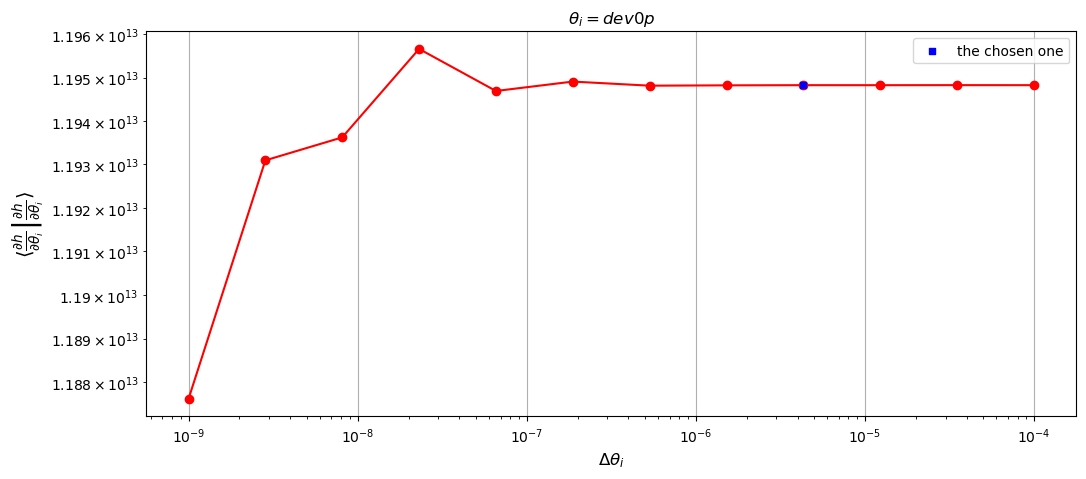

Gamma_ii for dev0e: 711317458075.8818
Gamma_ii for dev0e: 711317549022.0441
Gamma_ii for dev0e: 711320601032.9893
Gamma_ii for dev0e: 711326138259.4845
Gamma_ii for dev0e: 711308166643.416
Gamma_ii for dev0e: 711278639883.6561
Gamma_ii for dev0e: 711449434723.3475
Gamma_ii for dev0e: 711012413753.9432
Gamma_ii for dev0e: 711371017539.4885
Gamma_ii for dev0e: 703478391351.1382
Gamma_ii for dev0e: 722531554386.9164
Gamma_ii for dev0e: 706957806367.4269
[np.float64(1.278559236398466e-07), np.float64(4.290626393722126e-06), np.float64(7.784370905852098e-06), np.float64(2.5265583767001437e-05), np.float64(4.151222615755393e-05), np.float64(0.0002400660276830793), np.float64(0.0006146460468910107), np.float64(0.0005041023273419792), np.float64(0.01121942945993173), np.float64(0.026370008230222165), np.float64(0.022029246836543684)]
0


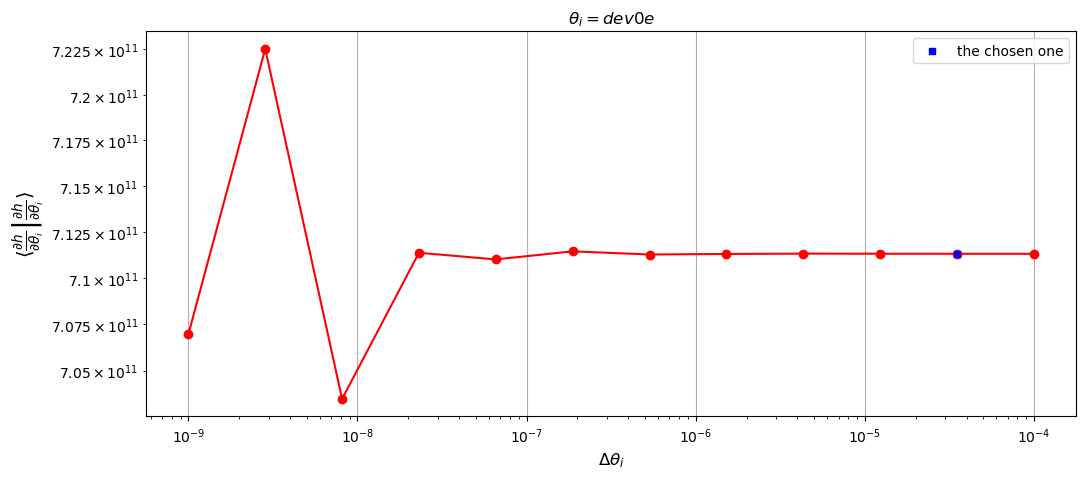

stable deltas: {'m1': 35.11191734215131, 'm2': 0.0003511191734215131, 'a': 2.8089533873721088e-05, 'p0': 0.0002457834213950592, 'e0': 1.4044766936860542e-05, 'qS': 0.00339980115994862, 'phiS': 0.004328761281083062, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': 4.328761281083061e-06, 'dev0e': 3.511191734215135e-05}
Time taken to compute stable deltas is 133.373765707016 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 11.587126016616821 seconds


In [9]:
#initialize the 0PA (approximate) model
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}


param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}
der_order = 8
Ndelta = 12

Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,
            )


In [10]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J

In [11]:
Fisher[-1].shape

(11, 11)

In [12]:
fisher_=Fisher[-1].copy()
fisher_
# sef.deltas["Phi_phi0"] = 1e-5
# sef.deltas["Phi_r0"] = 1e-5
sef.deltas

{'m1': 35.11191734215131,
 'm2': 0.0003511191734215131,
 'a': 2.8089533873721088e-05,
 'p0': 0.0002457834213950592,
 'e0': 1.4044766936860542e-05,
 'qS': 0.00339980115994862,
 'phiS': 0.004328761281083062,
 'Phi_phi0': 0.0,
 'Phi_r0': 0.0,
 'dev0p': 4.328761281083061e-06,
 'dev0e': 3.511191734215135e-05}

In [13]:
#in this code cell, we are transfroming fisher for numerical stability and will remove parameters that are causing problem

print("Transforming to log-mass")
Fisher_transform = logmasstransform(fisher_, m1)
print("Checking log-mass Fisher positive-definiteness...")
check_flag = True
rows_to_remove = []
for j in range(len(param_names)):
    if param_names[j] in []:#'dist','qS','phiS','qK','phiK','Phi_phi0','Phi_r0']:
            rows_to_remove.append(j)

rows_to_remove = np.array(rows_to_remove)
    
if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(np.delete(Fisher_transform,rows_to_remove,axis=0),rows_to_remove,axis=1)
    #Fisher = np.delete(np.delete(Fisher,rows_to_remove,axis=0),rows_to_remove,axis=1)

if (np.linalg.eigvals(Fisher_transform) < 0.0).any():
    check_flag = False
    print('positive definiteness failed for: ', i)
        
if check_flag:
    print("positive-definiteness check passed!")
pd.DataFrame(Fisher_transform)

Transforming to log-mass
Checking log-mass Fisher positive-definiteness...
positive-definiteness check passed!


,0,1,2,3,4,5,6,7,8,9,10
0,1.130011e+15,-1.404326e+13,1.248991e+14,2.455477e+14,7.426527e+14,-4.237370e+09,1.953153e+10,-5.119555e+09,-3.670134e+09,-1.123586e+14,-2.808673e+13
1,-1.404326e+13,1.842333e+11,-1.721635e+12,-3.079417e+12,-8.941056e+12,4.774898e+07,-2.200732e+08,5.768557e+07,3.780927e+07,1.483046e+12,3.594460e+11
2,1.248991e+14,-1.721635e+12,1.966060e+13,2.811600e+13,7.730595e+13,-4.415745e+08,2.035934e+09,-5.339600e+08,-2.041290e+08,-1.398561e+13,-3.232160e+12
3,2.455477e+14,-3.079417e+12,2.811600e+13,5.351941e+13,1.605900e+14,-9.164981e+08,4.224559e+09,-1.107383e+09,-7.637156e+08,-2.467278e+13,-6.124150e+12
4,7.426527e+14,-8.941056e+12,7.730595e+13,1.605900e+14,4.966872e+14,-2.939486e+09,1.354972e+10,-3.551619e+09,-2.646276e+09,-7.127883e+13,-1.814005e+13
5,-4.237370e+09,4.774898e+07,-4.415745e+08,-9.164981e+08,-2.939486e+09,2.411016e+04,-1.005667e+05,2.636536e+04,1.884815e+04,3.794586e+08,9.807517e+07
6,1.953153e+10,-2.200732e+08,2.035934e+09,4.224559e+09,1.354972e+10,-1.005667e+05,4.651239e+05,-1.215735e+05,-8.687297e+04,-1.748923e+09,-4.520269e+08
7,-5.119555e+09,5.768557e+07,-5.339600e+08,-1.107383e+09,-3.551619e+09,2.636536e+04,-1.215735e+05,3.187610e+04,2.276050e+04,4.584326e+08,1.184800e+08
8,-3.670134e+09,3.780927e+07,-2.041290e+08,-7.637156e+08,-2.646276e+09,1.884815e+04,-8.687297e+04,2.276050e+04,2.465389e+04,2.956737e+08,8.245940e+07
9,-1.123586e+14,1.483046e+12,-1.398561e+13,-2.467278e+13,-7.127883e+13,3.794586e+08,-1.748923e+09,4.584326e+08,2.956737e+08,1.194827e+13,2.883459e+12


In [14]:
delats=sef.deltas
param_name = sef.param_names

In [15]:
parameters = {}
for i in range(len(param_names_com)):
    parameters[param_names_com[i]] = pars_list_com[i]


order = 8 #order of finite-difference derivative
kind = "central" #kind of finite-difference derivative
parameters

{'m1': 1000000.0,
 'm2': 10,
 'a': 0.8,
 'p0': 7.0,
 'e0': 0.4,
 'xI0': 1.0,
 'dist': 0.4,
 'qS': 0.7853981633974483,
 'phiS': 1.0,
 'qK': 1,
 'phiK': 1.0471975511965976,
 'Phi_phi0': 0.9,
 'Phi_theta0': 0.5,
 'Phi_r0': 0.4,
 'chi2': 0.0,
 'evolve_1PA': False,
 'evolve_primary': False,
 'evolve_2PA': False,
 'deviation_included': True,
 'dev0p': 0.0,
 'dev0e': 0.0,
 'dev1p': 0.0,
 'dev1e': 0.0,
 'dev2p': 0.0,
 'dev2e': 0.0}

In [16]:
# del sef
sef.wave_params_list

[1000000.0,
 10,
 0.8,
 7.0,
 0.4,
 1.0,
 0.4,
 0.7853981633974483,
 1.0,
 1,
 1.0471975511965976,
 0.9,
 0.5,
 0.4,
 0.0,
 False,
 False,
 False,
 True,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [17]:
sef.waveform_derivative_kwargs

{'parameters': {'m1': 1000000.0,
  'm2': 10,
  'a': 0.8,
  'p0': 7.0,
  'e0': 0.4,
  'xI0': 1.0,
  'dist': 0.4,
  'qS': 0.7853981633974483,
  'phiS': 1.0,
  'qK': 1,
  'phiK': 1.0471975511965976,
  'Phi_phi0': 0.9,
  'Phi_theta0': 0.5,
  'Phi_r0': 0.4,
  'chi2': 0.0,
  'evolve_1PA': False,
  'evolve_primary': False,
  'evolve_2PA': False,
  'deviation_included': True,
  'dev0p': 0.0,
  'dev0e': 0.0,
  'dev1p': 0.0,
  'dev1e': 0.0,
  'dev2p': 0.0,
  'dev2e': 0.0},
 'order': 8,
 'dt': 10.0,
 'T': 0.5}

In [18]:
print(f"Calculating Cutler-Vallisneri Biases")
removed_params = []
print(f'calculating derivatives at {param_names}...')
#Fisher = np.zeros((sef.npar,sef.npar), dtype=np.float64)
dtv = []

for k in range(sef.npar):
        temp=sef.derivative(*sef.wave_params_list,
                             param_to_vary=sef.param_names[k],
                               delta=sef.deltas[sef.param_names[k]],
                               kind=kind, **sef.waveform_derivative_kwargs,use_gpu=use_gpu)
        print(temp)
        print("\n",temp.shape)
        print(f"calculting derivative for {sef.param_names[k]}\n")
        dtv_=np.vstack([temp.real,temp.imag])
        print(dtv_)
        dtv.append(dtv_)
        

print("Finished derivatives")
if sef.use_gpu:
        dtv = cp.asnumpy(cp.asarray(dtv)) #h5py only stores numpy
          
#Jacobian transform to log-masses
for k in range(sef.npar):
    if sef.param_names[k] == 'm1':
        dtv[k] *= m1 #to obtain \partial_{log m1}h

Calculating Cutler-Vallisneri Biases
calculating derivatives at ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0', 'dev0p', 'dev0e']...
[1.62301902e-32+5.06480266e-33j 1.54310212e-28-1.96036328e-28j
 3.93677062e-28-2.64687612e-28j ... 4.08407827e-22-2.47445818e-23j
 4.14143651e-22+1.03914144e-22j 3.78131339e-22+2.36864214e-22j]

 (1577908,)
calculting derivative for m1

[[ 1.62301902e-32  1.54310212e-28  3.93677062e-28 ...  4.08407827e-22
   4.14143651e-22  3.78131339e-22]
 [ 5.06480266e-33 -1.96036328e-28 -2.64687612e-28 ... -2.47445818e-23
   1.03914144e-22  2.36864214e-22]]
[ 1.62301919e-22+5.06479749e-23j  1.37684739e-22+9.50471717e-23j
  1.02153878e-22+1.28052522e-22j ... -6.66844437e-18+2.83498315e-19j
 -6.68277820e-18-1.79662916e-18j -6.03043144e-18-3.90963193e-18j]

 (1577908,)
calculting derivative for m2

[[ 1.62301919e-22  1.37684739e-22  1.02153878e-22 ... -6.66844437e-18
  -6.68277820e-18 -6.03043144e-18]
 [ 5.06479749e-23  9.50471717e-23  1.28052522e-22 ...

In [19]:
params_truth_in = np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])
#params_truth_in_transformed = np.array([np.log(m1), m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,dev_0_p,dev_0_e])

# param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0,Phi_r0,dev_0_p,dev_0_e])
#params_truth_in_considered = np.array([np.log(m1), m2, a, p0, e0, dev_0_p, dev_0_e])
print(params_truth_in_considered)
waveform_approx = sef.waveform
waveform_approx

[13.81551056 10.          0.8         7.          0.4         0.78539816
  1.          0.9         0.4         0.          0.        ]


array([[ 8.11517709e-22,  6.88429738e-22,  5.10772373e-22, ...,
         2.83553469e-24, -2.17230661e-22, -4.29960302e-22],
       [-2.53242407e-22, -4.75241645e-22, -6.40270385e-22, ...,
        -7.11331867e-22, -6.91515329e-22, -6.01539617e-22]],
      shape=(2, 1577908))

In [20]:
#initializing the 1PA (True GR model in our analysis)
evolve_1PA = True 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
print(add_args)
waveform_true = superkludge_wave(m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)

[0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


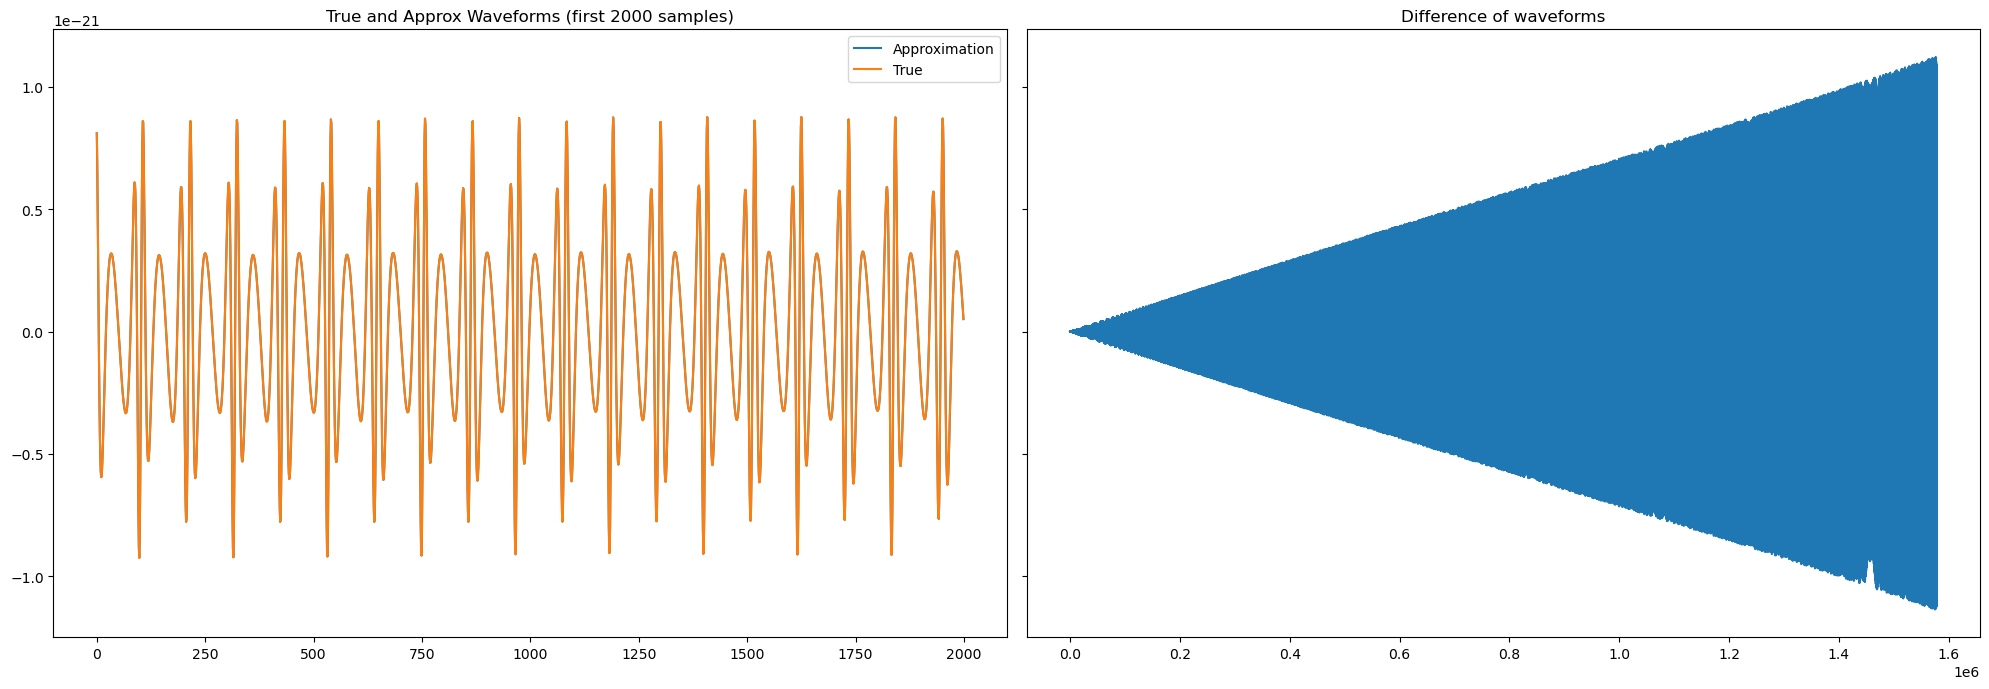

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Plot the first 2000 samples of both waveforms
axs[0].plot(waveform_approx[0][0:2000].get(), label="Approximation")
axs[0].plot(waveform_true[0][0:2000].get(), label="True")
axs[0].set_title("True and Approx Waveforms (first 2000 samples)")
axs[0].legend()

# Plot the difference
axs[1].plot(((waveform_true[0] - waveform_approx[0])[0:]).get())
axs[1].set_title("Difference of waveforms")

plt.tight_layout()

In [22]:
biased_params = cutlervallis(waveform_truth=waveform_true, waveform_approx=waveform_approx,
                                 Fisher_truth=Fisher_transform, partial_approx=dtv,
                                 params_truth=params_truth_in_considered, PSD_func = sef.PSD_funcs, dt = dt,
                                  use_gpu=use_gpu)
print(biased_params)

if use_gpu:
        biased_params = cp.asnumpy(cp.asarray(biased_params))

#prior box on chi2
# if 'chi2' not in removed_params:
#     index_chi2 = np.where(param_names == 'chi2')
        
#     if biased_params[index_chi2] > 1.0:
#         biased_params[index_chi2] = 1.0
#     elif biased_params[index_chi2] < -1.0:
#         biased_params[index_chi2] = -1.0

#prior box on cyclic parameters (phases and such)
cyclic_priors = {'qS' : np.pi, 'phiS' : 2 * np.pi, 'qK' : np.pi, 'phiK' : 2 * np.pi, 'Phi_phi0' : 2 * np.pi, 'Phi_r0' : 2 * np.pi}
param_names_in = np.array(param_names)
for param in list(cyclic_priors.keys()):
    if param not in removed_params:
        print(f"modulo {cyclic_priors[param]} for param {param}")
            
        index = np.where(param_names_in == param) 
        biased_params[index] %= cyclic_priors[param]


print('biased params: ', biased_params)

#calculate the sigma contour as the Mahalanobis distance between the true and biased params (https://en.wikipedia.org/wiki/Mahalanobis_distance):
    
sigma_contour = np.sqrt((biased_params - params_truth_in_considered)@Fisher_transform@(biased_params - params_truth_in_considered))
sigma_contour /= np.sqrt(len(params_truth_in_considered)) #scaled Mahalonobis distance for dimensional generality
    
print('sigma contours: ', sigma_contour)

delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 0:  -183772.81531802093
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 1:  2221.09851326937
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 2:  -19095.544617014304
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 3:  -39731.536813973464
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 4:  -122659.86022027256
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 5:  5.559213648640676
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 6:  -0.43508884546652055
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 7:  0.8553872962479802
delta_wave.shape, partial_approx.shape:  (2, 1577908) (2, 1577908)
inner_prod at j = 8:  0.640196442445177
delta_wave.shape, partial_

In [23]:
print(sigma_contour)

0.040647546777364076


In [24]:
biased_params

array([1.38155138e+01, 9.99705529e+00, 8.00001939e-01, 6.99998875e+00,
       3.99999074e-01, 7.87924775e-01, 1.00205640e+00, 9.05748273e-01,
       4.00015327e-01, 2.97132034e-04, 2.99393734e-04])

In [25]:
params_truth_in_considered

array([13.81551056, 10.        ,  0.8       ,  7.        ,  0.4       ,
        0.78539816,  1.        ,  0.9       ,  0.4       ,  0.        ,
        0.        ])

# plot ig

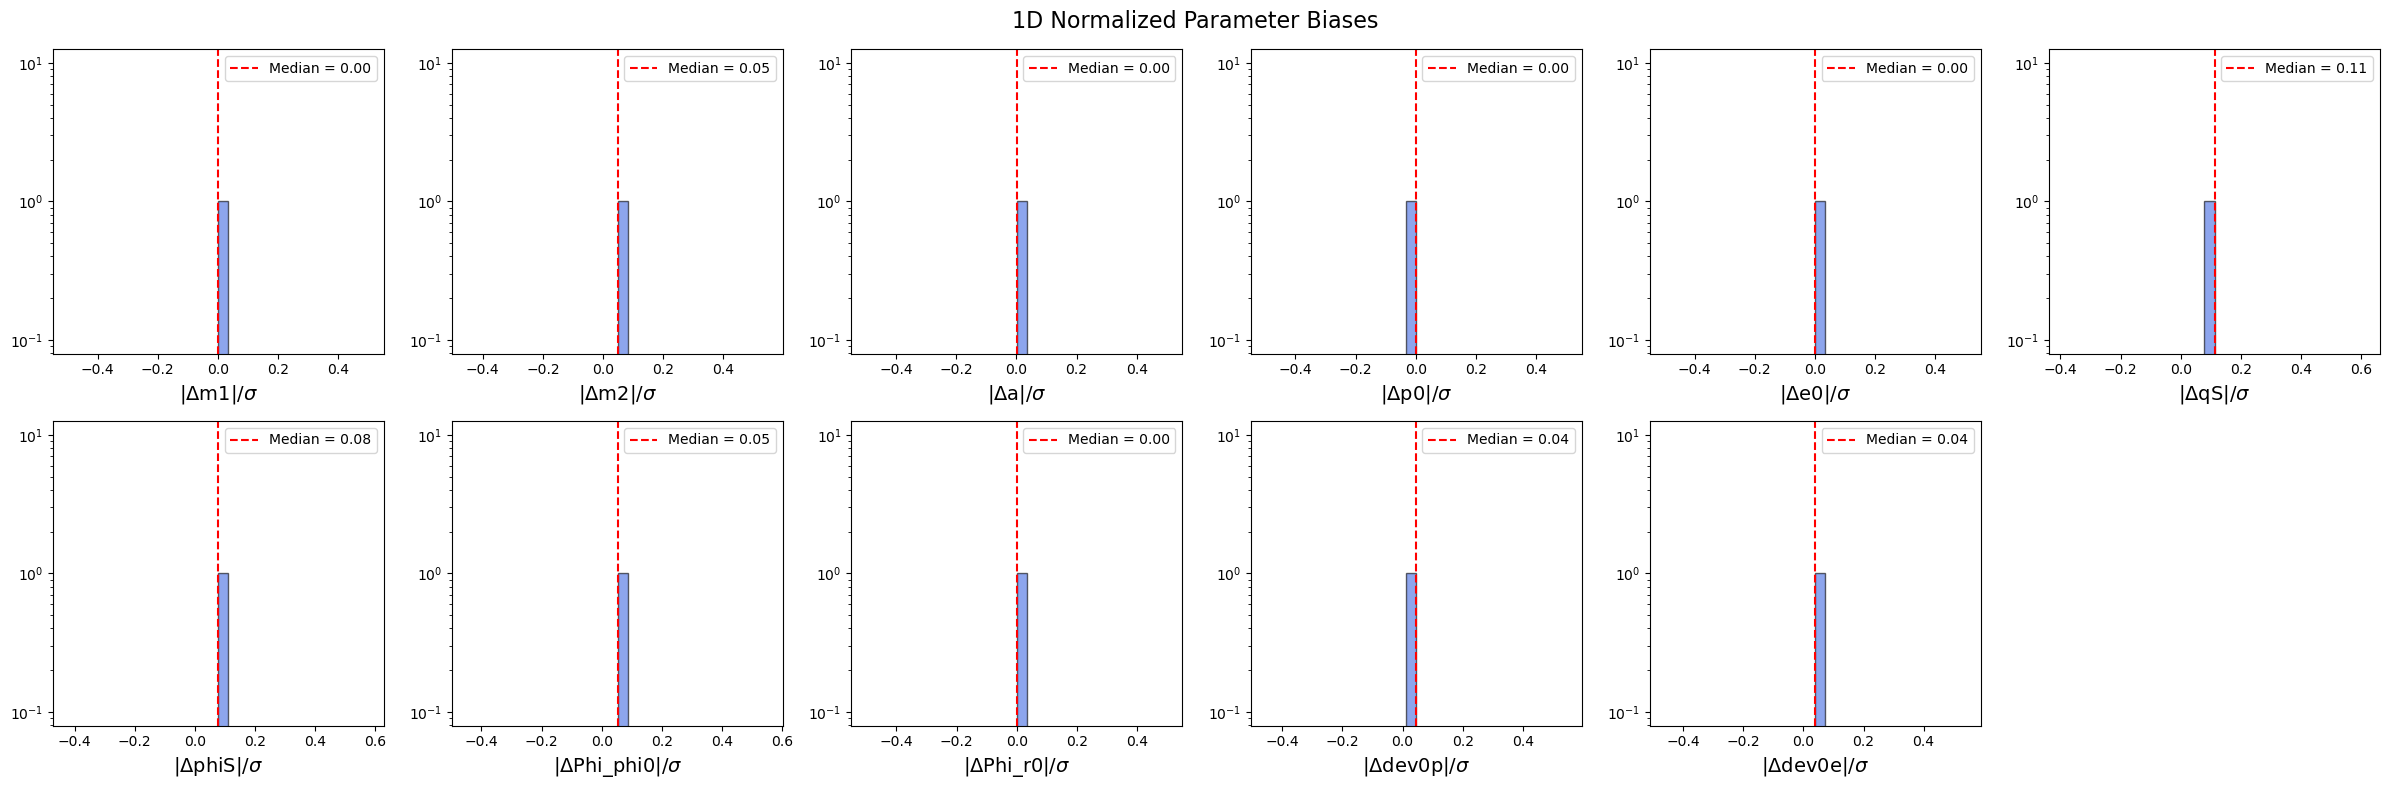

In [26]:
#used gpt (boring part)

# === PARAMETERS ===
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']


params_truth_in_considered = np.array([
    np.log(m1), m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_0_p, dev_0_e
])
truevals_i = params_truth_in_considered

Fisher_transformed = Fisher_transform.copy()

# === REMOVE PARAMETERS IF SPECIFIED ===
rows_to_remove = [i for i, name in enumerate(param_names) if name in removed_params]
rows_to_remove = np.array(rows_to_remove)

if len(rows_to_remove) > 0:
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=0)
    Fisher_transformed = np.delete(Fisher_transformed, rows_to_remove, axis=1)
   # param_names_plot = np.delete(param_names_plot, rows_to_remove, axis=0)
    truevals_i = np.delete(truevals_i, rows_to_remove, axis=0)

# === COMPUTE SIGMAS ===
covariance = np.linalg.inv(Fisher_transformed)
sigmas_params = np.sqrt(np.diag(covariance))

# === COMPUTE NORMALIZED BIASES ===
sigmabias_1D = np.abs(biased_params - truevals_i) / sigmas_params

# === PLOT ===
n_params = len(param_names)
ncols = int(np.ceil(n_params / 2))

fig, axs = plt.subplots(2, ncols, figsize=(4 * ncols, 8))
axs = axs.flatten()

for i, name in enumerate(param_names):
    axs[i].hist(sigmabias_1D[i], bins=30, histtype='stepfilled',
                color='royalblue', alpha=0.6, edgecolor='k')
    axs[i].set_xlabel(r"$|\Delta $" + rf"{name}" + r"$|/\sigma$", fontsize=14)
    axs[i].set_yscale('log')
    axs[i].axvline(np.median(sigmabias_1D[i]), color='r', linestyle='--',
                   label=f"Median = {np.median(sigmabias_1D[i]):.2f}")
    axs[i].legend(fontsize=10)

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle("1D Normalized Parameter Biases", fontsize=16)
plt.show()



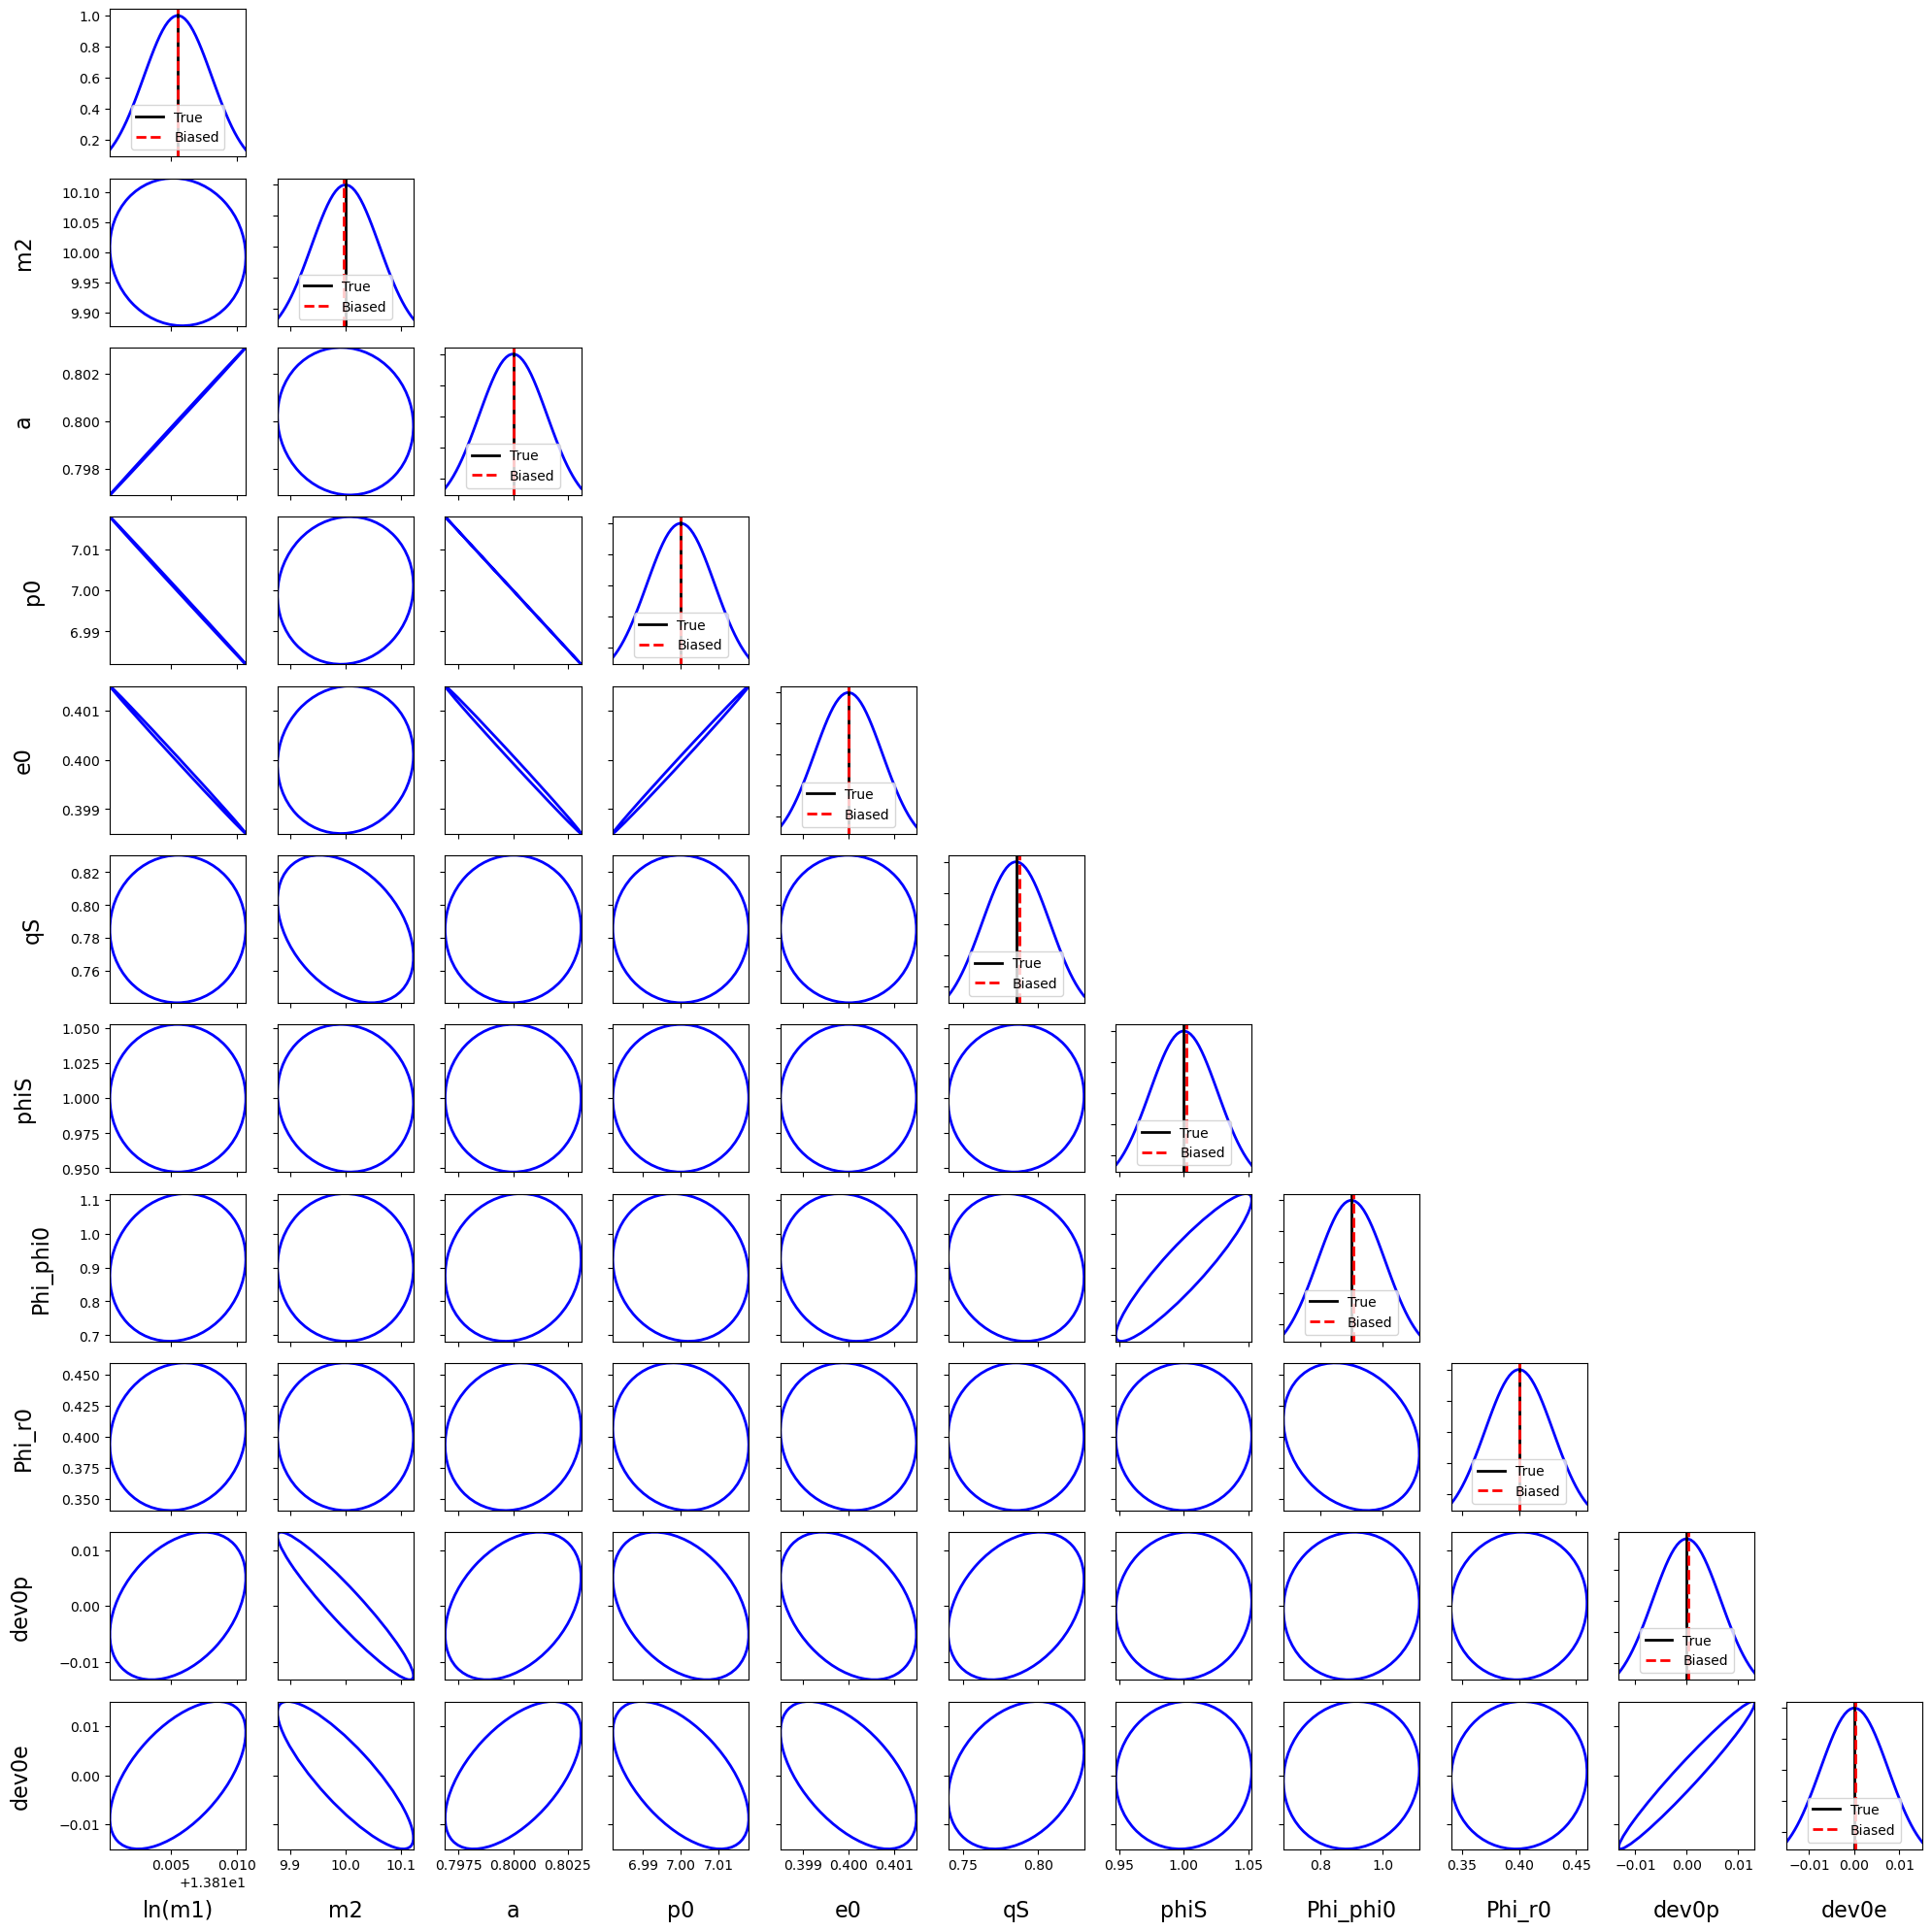

In [27]:
from stableemrifisher.plot import CovEllipsePlot
# pars_list = [m1, m2, p0, e0, dist,qS,phiS,Phi_phi0,Phi_r0,chi2]
# param_names = ['m1','m2','p0','e0','dist','qS','phiS','Phi_phi0','Phi_r0','chi2']
pars_list = params_truth_in_considered
# param_names_plot = [
#     r'$\log{m_1}$', r'$m_2$', r'$a$', r'$p_0$', r'$e_0$',
#     r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
#     r'dev0_p', r'dev0_e'
# ]
param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

wave_params = {}
for i in range(len(pars_list)):
    wave_params[param_names[i]] = params_truth_in_considered[i]

ellipse_kwargs = dict(facecolor='None', edgecolor='b', lw=2)
line_kwargs = dict(lw=2, color='b')

fig, axs = plt.subplots(len(covariance),len(covariance), figsize=(20,20))
fig, axs = CovEllipsePlot(covariance, wave_params=wave_params, param_names=param_names, fig=fig, axs=axs, ellipse_kwargs=ellipse_kwargs, line_kwargs=line_kwargs)
# === ADD TRUE AND BIASED PARAMETER LINES ===
for i in range(len(param_names)):
    # Diagonal subplot (1D)
    ax = axs[i, i]
    ax.axvline(params_truth_in_considered[i], color='k', linestyle='-', lw=2, label='True')
    ax.axvline(biased_params[i], color='r', linestyle='--', lw=2, label='Biased')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [28]:
biased_params

array([1.38155138e+01, 9.99705529e+00, 8.00001939e-01, 6.99998875e+00,
       3.99999074e-01, 7.87924775e-01, 1.00205640e+00, 9.05748273e-01,
       4.00015327e-01, 2.97132034e-04, 2.99393734e-04])

In [29]:
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
dev_0_p=biased_params[9]
dev_0_e=biased_params[10]
# param_names = ['ln(m1)','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']

dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
deviation_included=True
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

pars_list = [np.exp(biased_params[0]), biased_params[1], biased_params[2], biased_params[3], \
             biased_params[4], xI0, dist, biased_params[5], biased_params[6], qK, phiK, biased_params[7], Phi_theta0,\
               biased_params[8]]

superkludge_wave_biased = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)

waveform_biased = superkludge_wave_biased(*pars_list, *add_args, dt=dt, T=T)


In [30]:
deviation=params_truth_in_considered-biased_params
print("Higher",biased_params)
print("\nTrue",params_truth_in_considered)
print("\nlower",params_truth_in_considered+deviation)

Higher [1.38155138e+01 9.99705529e+00 8.00001939e-01 6.99998875e+00
 3.99999074e-01 7.87924775e-01 1.00205640e+00 9.05748273e-01
 4.00015327e-01 2.97132034e-04 2.99393734e-04]

True [13.81551056 10.          0.8         7.          0.4         0.78539816
  1.          0.9         0.4         0.          0.        ]

lower [ 1.38155073e+01  1.00029447e+01  7.99998061e-01  7.00001125e+00
  4.00000926e-01  7.82871552e-01  9.97943596e-01  8.94251727e-01
  3.99984673e-01 -2.97132034e-04 -2.99393734e-04]


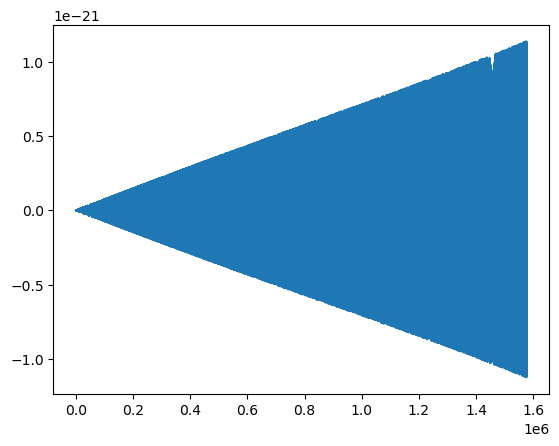

In [31]:
plt.plot((waveform_approx-waveform_true)[0].get())

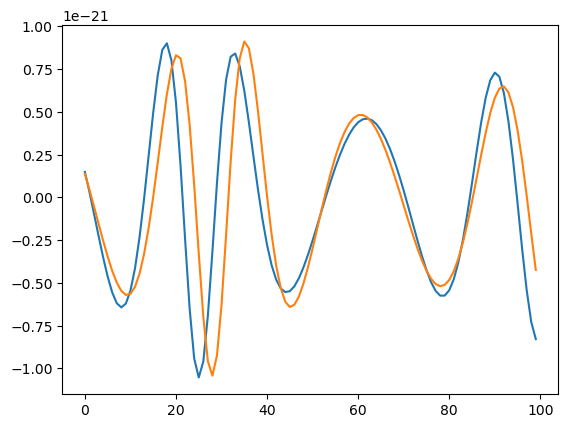

In [32]:
plt.plot((waveform_true)[0][-100:].get())
plt.plot((waveform_biased)[0][-100:].get())

In [33]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner=inner_product(waveform_biased,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_biased=np.sqrt(inner_product(waveform_biased,waveform_biased,PSD,dt,use_gpu=use_gpu))
diff_inner/((norm_true)*norm_biased)


np.float64(0.8587424254524265)

In [34]:
evolve_1PA = False 
evolve_primary = False
evolve_2PA = False #for approximate model
deviation_included=True
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0

deviation=biased_params-params_truth_in_considered

PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])

norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
delta = np.linspace(-1,1,500)
save_inner=[]
for i in range(len(delta)):
    biased = params_truth_in_considered + delta[i] * deviation
    dev_0_p= biased[9]
    dev_0_e= biased[10]
    add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
    add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,\
                    "deviation_included":deviation_included,"dev0p":dev_0_p,
        "dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

    pars_list = [np.exp(biased[0]), biased[1], biased[2], biased[3], \
             biased[4], xI0, dist, biased[5], biased[6], qK, phiK, biased[7], Phi_theta0,\
               biased[8]]
    waveform_considered = superkludge_wave_biased(*pars_list, *add_args, dt=dt, T=T,use_gpu=use_gpu)
    diff_inner=inner_product(waveform_considered,waveform_true,PSD,dt,use_gpu=use_gpu)
    norm_biased=np.sqrt(inner_product(waveform_considered,waveform_considered,PSD,dt,use_gpu=use_gpu))
    mismatch=diff_inner/((norm_true)*norm_biased)
   #print(mismatch)
    save_inner.append(mismatch)


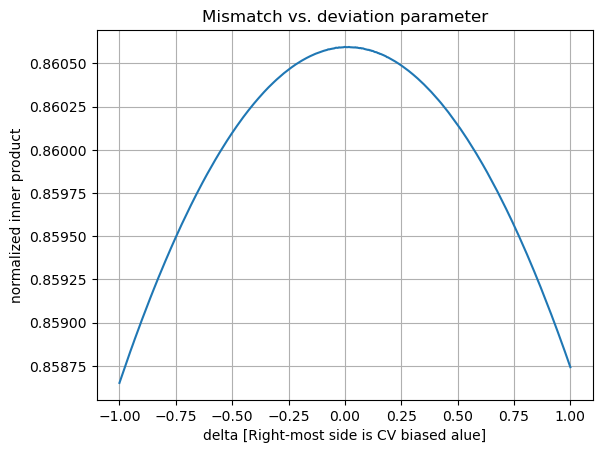

In [35]:
plt.plot(delta,save_inner)
plt.xlabel("delta [Right-most side is CV biased alue]")
plt.ylabel("normalized inner product")
plt.title("Mismatch vs. deviation parameter")
plt.grid(True)

In [36]:
print(np.max(save_inner))
delta[np.argmax(save_inner)]
#0.8587424254524265

0.8605957466563193


np.float64(0.018036072144288484)

In [37]:
print(np.max(save_inner))
delta[np.argmax(save_inner)]
#0.8587424254524265

0.8605957466563193


np.float64(0.018036072144288484)

In [38]:
print(np.max(save_inner))
delta[np.argmax(save_inner)]
#0.8587424254524265

0.8605957466563193


np.float64(0.018036072144288484)

# points
1. select mode to reduce noise
2. Discuss with Miaoxin